#Data Mining project ENRICO SCHIAZZANO, 1167670.


## **Objective of the project**
In this project we are going to perform some **classification** techniques on the *Breast Cancer Wisconsin (Diagnostic)* dataset. This dataset contains 569 samples computed from digitized images of breast masses, describing characteristics of the cell nuclei present in the image, such as radius, texture or concavity, and classifying each mass as benign or malignant.
We will use these labels to assess the validity of our methods.

## **0 Preprocessing**

In this first part, the focus is on **data preprocessing**. The main objective is to transform the original dataset into a numerical and consistent format, ready to be fed to the classification models, without using any prior information about the target variable.

The dataset contains a variable called `diagnosis`, which indicates whether a tumor is *benign* or *malignant*. This variable represents the ground truth label.

## 0.1 Import of Libraries

We import the Python libraries we will use in this project.

- **pandas** and **numpy** are used for data manipulation and numerical operations;
- **matplotlib** and **seaborn** are used for basic data visualization;
- **math** for mathematical operations;
- **StandardScaler** will be used to normalize the data, which is crucial here since our features live on very different scales;
- **train_test_split** is used to create the training and testing sets, useful for classification evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 0.2 Loading the Dataset

We load the Breast Cancer Wisconsin (Diagnostic) dataset.
Each row represents a single tumor sample, while each column corresponds to a specific numerical attribute describing the cell nuclei of the mass.

The features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. For each of ten base measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension), three statistics are reported across the nuclei in the image: the **mean**, the **standard error** and the **worst** (largest) value, giving 30 features in total.

We could download the dataset from UCI or use it directly from `scikit-learn`, we choose this second option without depending on external downloads.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

#We choose to keep the encoding of 0=malignant, 1=benign
df = df.rename(columns={"target": "diagnosis"})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 0.3 Dataset Dimensions and Structure

In order to better understand the structure of the data, we first analyze the size and the general information of the dataset.
The dataset contains **569 observations** and **31 variables** (30 numerical features plus the target).

In [ ]:
df.shape

(569, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 0.4 Overview of the Variables

The dataset includes one target variable, called `diagnosis`, and thirty explanatory variables describing the geometry and texture of the cell nuclei.

In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

Now we can give a description of the variables included in the dataset.
- **diagnosis**: Indicates whether the tumor is benign or malignant
  - *0* = malignant
  - *1* = benign

The remaining thirty variables come from ten base measurements computed on the boundary of each cell nucleus. Each measurement is reported as *mean*, *standard error* and *worst* (the mean of the three largest nuclei in the image), giving 30 features in total.
- **radius**: Mean distance from the center of the nucleus to points on its perimeter.
- **texture**: Standard deviation of the gray-scale intensity values of the pixels inside the nucleus. It measures how uniform or "grainy" the nucleus looks: a smooth, uniform nucleus has low texture, an irregular one has high texture.
- **perimeter**: Length of the nucleus contour.
- **area**: Number of pixels inside the nucleus contour, i.e. its size.
- **smoothness**: Local variation in the radius lengths. For each boundary point the radius is compared to the average of its neighbours; small differences mean a smooth, regular contour, large differences mean a jagged one.
- **compactness**: Computed as perimeter² / area − 1.0. It quantifies how far the shape is from a perfect circle: irregular, elongated shapes give higher values.
- **concavity**: Severity of the concave portions of the contour. It measures how deep the dents in the boundary are.
- **concave points**: Number of concave portions of the contour, i.e. how many indentations there are.
- **symmetry**: Degree of symmetry of the nucleus. A longest "chord" through the center is taken, and the lengths of segments perpendicular to it are compared on the two sides; the more the two sides differ, the less symmetric the nucleus and the higher this value.
- **fractal dimension**: "Coastline approximation" − 1.0. It captures how irregular and detailed the contour is by measuring how the apparent perimeter changes as the measuring scale shrinks. A smooth boundary stays close to dimension 1 (a line), while a rough, jagged boundary behaves as if it were filling space and gives a higher value.

Unlike many classic datasets, all these variables are **numerical and continuous**. This means that, instead of countplots and categorical encoding, the natural tools for exploration are histograms, boxplots and correlation analysis, and the natural preprocessing step is feature scaling. Note also that several of these measurements are geometrically linked (radius, perimeter and area describe the same object), so we expect strong correlations among some of them.

## 0.5 Distributions of the Variables
In this section, we explore the distribution of all the numerical variables using histograms. Since the features are continuous, histograms are the appropriate tool to observe how the values are spread.
The goal is to observe the shape of each feature, identify skewness, and spot variables whose values seem to separate the two classes well.

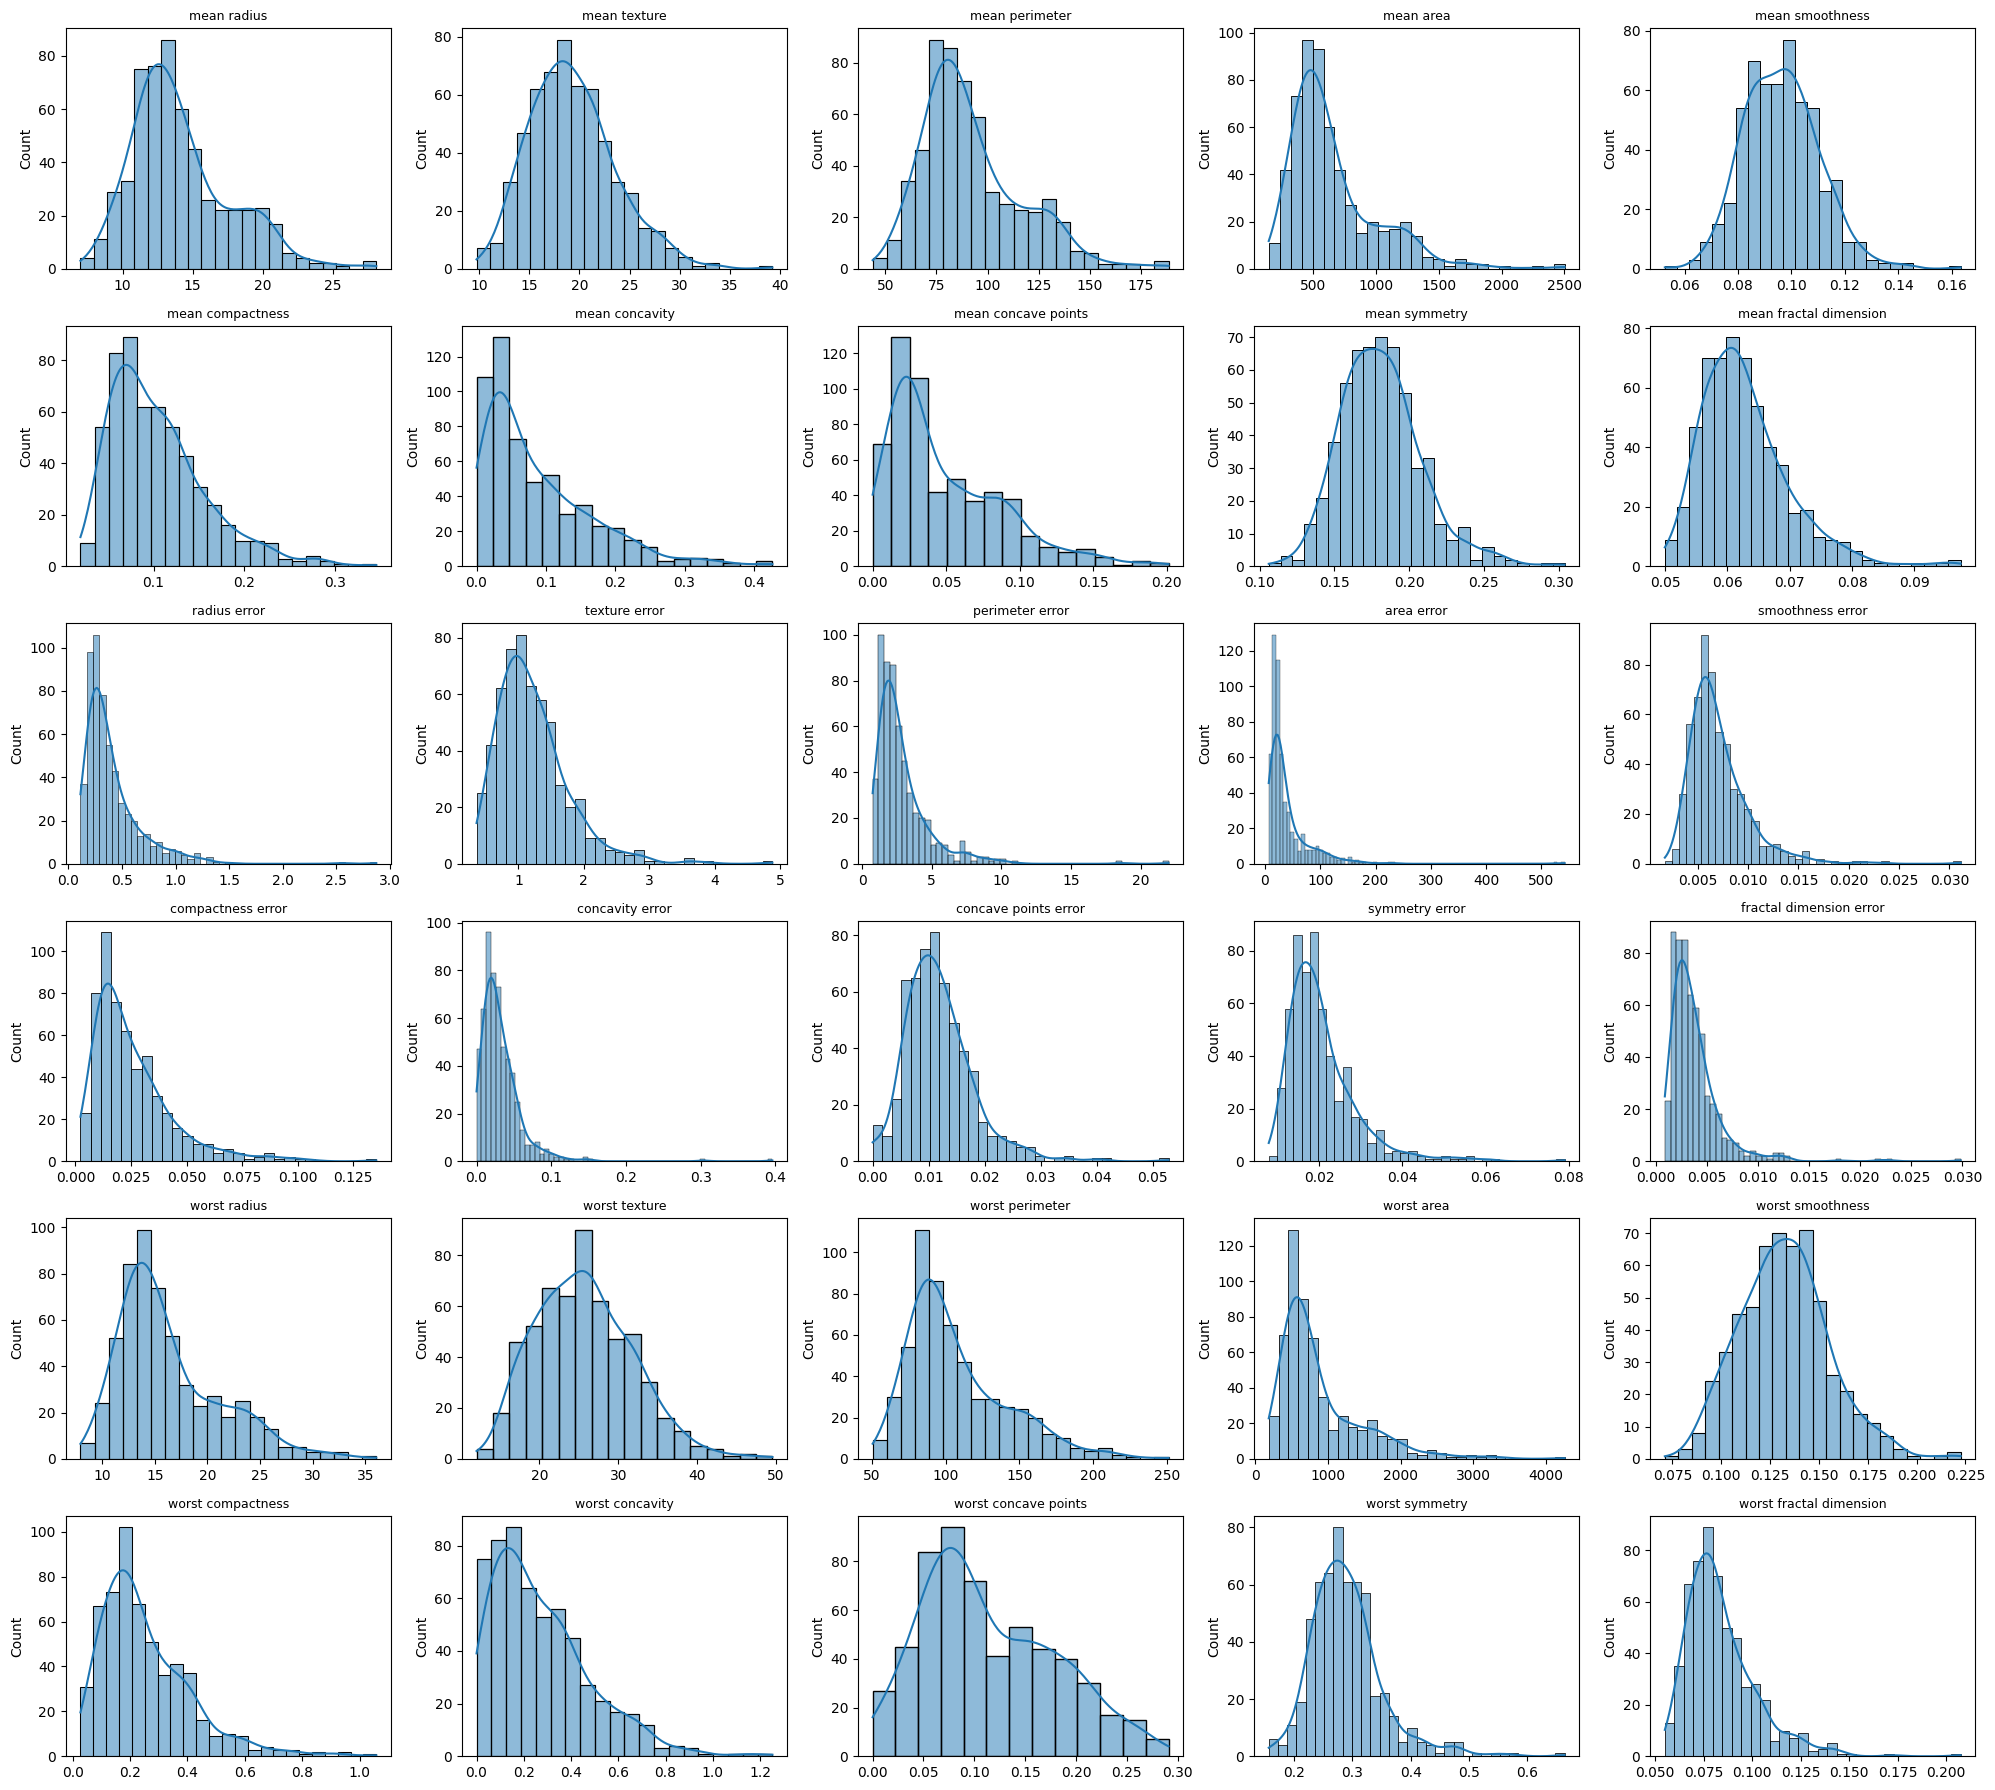

In [ ]:
feature_cols = df.columns.drop("diagnosis")
n_features = len(feature_cols)
n_cols = 5
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

Let us analyze some of these distributions.

Many features are clearly **right-skewed**: most samples take small values while a long tail of larger values is present. This is very evident for `mean area`, `mean concavity`, `mean concave points`, and for almost all the `error` features (`radius error`, `perimeter error`, `area error`), where the bulk of the data is squeezed on the left and a few nuclei reach much larger values. This shape is typical of size- and irregularity-related quantities that are bounded below by zero but can grow large for the most abnormal nuclei.

Other features are instead roughly **bell-shaped**, resembling a normal distribution: this is the case of `mean texture`, `mean smoothness`, `mean symmetry`, and especially `worst texture` and `worst smoothness`, which are the most symmetric of all.

A pattern worth noticing is the **mean / error / worst** structure of the features. The `error` versions, being standard errors, are almost always strongly right-skewed and concentrated near zero, since for most images the measurement is stable and only a few present large variability. The `worst` versions, being the average of the three most extreme nuclei, are systematically shifted towards larger values than the corresponding `mean` versions, which is exactly what we would expect from a statistic built on the most abnormal cells.

Finally, it is worth noticing the very different **scales** of the variables: `mean area` reaches the thousands and `worst area` goes up to 4000, while `mean smoothness` and `mean fractal dimension` stay around 0.1. This confirms that a normalization step will be necessary before applying distance-based methods such as KNN or SVM, otherwise the large-scale features would dominate the distance computation.

## 0.6 Distribution of the Target Variable
Before relating the features to the target, we look at the balance of the two classes, since this directly affects which evaluation metrics are appropriate for the classification task.

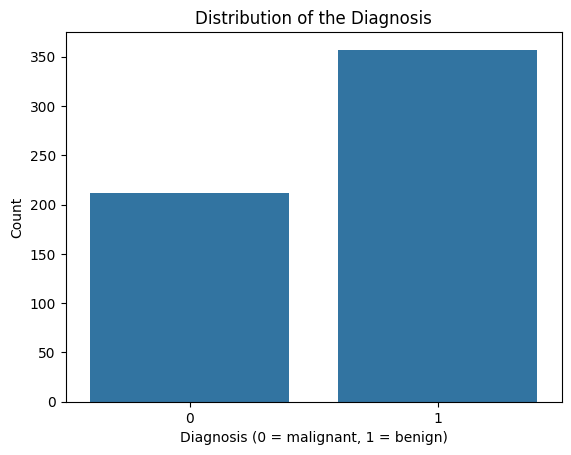

diagnosis
1    357
0    212
Name: count, dtype: int64


In [ ]:
sns.countplot(x="diagnosis", data=df)
plt.title("Distribution of the Diagnosis")
plt.xlabel("Diagnosis (0 = malignant, 1 = benign)")
plt.ylabel("Count")
plt.show()

print(df["diagnosis"].value_counts())

The two classes are **not perfectly balanced**: benign cases (357) are more frequent than malignant ones (212), roughly a 63% / 37% split. This is a mild imbalance, not a severe one, so accuracy remains a reasonable headline metric: predicting always the majority class would only reach about 63%, so a good accuracy still carries real information.

Nonetheless, the imbalance is not negligible, and more importantly the cost of the two possible errors is **asymmetric** in this medical setting: classifying a malignant tumor as benign is far more dangerous than the opposite. For this reason we will not rely on accuracy alone. Throughout the classification task we will also use the **confusion matrix** and the **classification report**, which expose precision, recall and f1-score separately for each class and let us check how well the malignant tumors in particular are identified. We will also include a **rule-based classifier (RIPPER)**, since the classes are not perfectly balanced.

## 0.7 Relationship between Features and the Target Variable

In this section, we perform an exploratory supervised analysis to investigate the relationship between some selected features and the target variable `diagnosis`.
The objective is to understand how the distribution of feature values differs between benign and malignant tumors, and to identify variables that may be informative for classification.
Since the features are continuous, the appropriate tool here is a boxplot grouped by class: we put the class on the x-axis and the continuous feature on the y-axis, so that a clear vertical separation between the two boxes signals a discriminative feature.

### Relationship between Mean Concave Points and Diagnosis

The boxplot shows how the distribution of `mean concave points` differs between benign and malignant tumors.

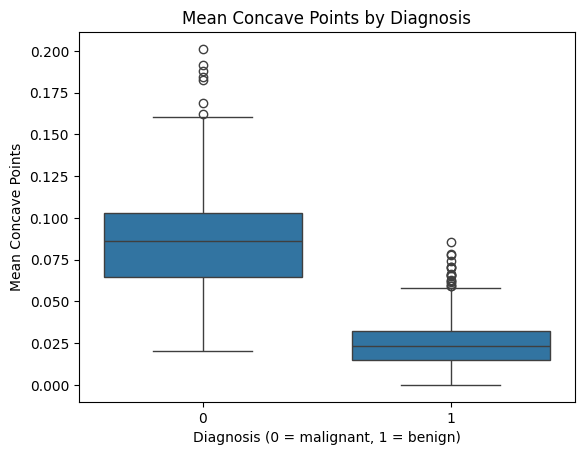

In [ ]:
sns.boxplot(x="diagnosis", y="mean concave points", data=df)
plt.title("Mean Concave Points by Diagnosis")
plt.xlabel("Diagnosis (0 = malignant, 1 = benign)")
plt.ylabel("Mean Concave Points")
plt.show()

Malignant tumors (class `0`) show clearly higher values of `mean concave points`, with very little overlap between the two boxes: the two distributions are almost disjoint.
This strong separation suggests that `mean concave points` is highly informative for the classification task. This single feature already separates the two classes quite well. This is consistent with the medical intuition that malignant nuclei tend to have more irregular, indented contours.

### Relationship between Mean Smoothness and Diagnosis

For comparison, we look at `mean smoothness`, which from the histograms appeared less skewed and which we expect to be less discriminative.

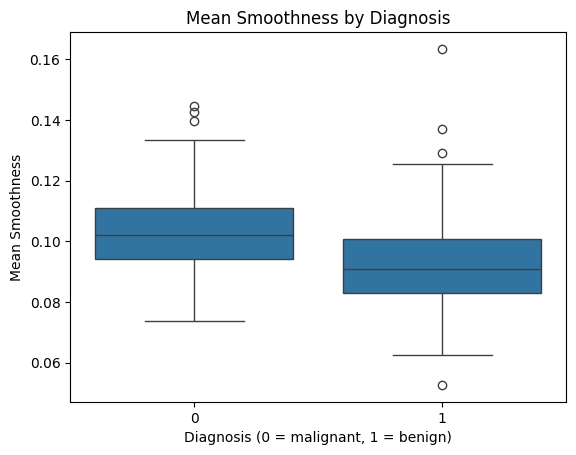

In [ ]:
sns.boxplot(x="diagnosis", y="mean smoothness", data=df)
plt.title("Mean Smoothness by Diagnosis")
plt.xlabel("Diagnosis (0 = malignant, 1 = benign)")
plt.ylabel("Mean Smoothness")
plt.show()

For `mean smoothness` the two boxes are shifted only slightly and overlap substantially: malignant tumors tend to have marginally higher values, but the two distributions are far from separated.
Compared to `mean concave points`, this feature does not provide a clear separation between classes, and on its own would be a weak predictor. Comparing these two boxplots illustrates a key point of exploratory analysis: not all features are equally useful, and identifying the few strongly discriminative ones helps to interpret the behaviour of the classifiers later on.

## 0.8 Correlation Matrix of the Features

The correlation matrix shows the pairwise linear correlations between the numerical features. Since all our features are genuine continuous measurements of the cell nuclei, we expect to observe **real correlations**, strong among related quantities and weak among unrelated ones. In particular, the features `radius`, `perimeter` and `area` are geometrically linked, since they all describe the size of the same nucleus, and should therefore be almost perfectly correlated.

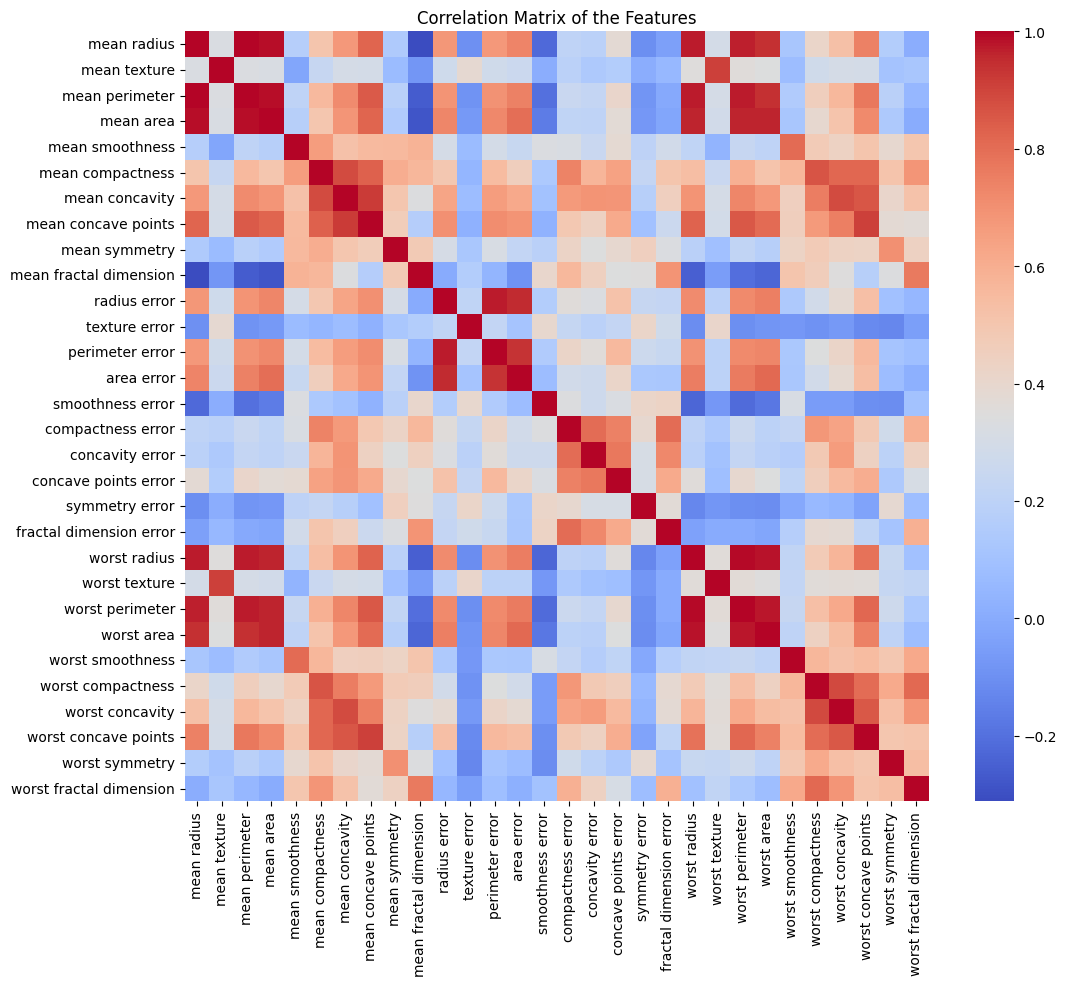

In [ ]:
corr_matrix = df.drop(columns=["diagnosis"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of the Features")
plt.show()

As expected, the heatmap reveals clear blocks of strong positive correlation rather than a uniform pattern around zero. The most evident block involves `radius`, `perimeter` and `area`, in all three mean/error/worst variants, which are almost perfectly correlated with one another. A second visible group links `concavity`, `concave points` and `compactness`, which all capture how irregular and indented the contour is.

This confirms the presence of substantial **multicollinearity** in the dataset. Several features are therefore largely redundant. This observation is important for the interpretation of the models that follow. In particular, Gaussian Naive Bayes assumes conditional independence between features, an assumption clearly violated here; we should therefore not be surprised if it performs slightly worse than other methods.

## 0.9 Missing Values
Handling missing values is normally an essential step of preprocessing, since most models cannot be trained on incomplete data and missing entries can introduce bias. We therefore check whether our dataset contains any.

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


The dataset does not contain any missing value: every feature is complete for all 569 samples. No imputation or removal of incomplete records is therefore required, and we can proceed directly to splitting the data.

## 0.10 Splitting the Dataset
The last step before classification is to divide the dataset into a training set and a test set, used respectively to train the models and to evaluate them on data never seen during training. This separation is what allows us to estimate how well a model generalizes, rather than how well it memorizes.
We use a stratified split, so that the benign/malignant proportion is preserved in both sets, which matters given the mild class imbalance observed earlier.

In [ ]:
# convert to numpy arrays for model input
X = df.drop(columns=["diagnosis"]).to_numpy()
y = df["diagnosis"].to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=102, shuffle=True, stratify=y
)

In [ ]:
X_train.shape

(455, 30)

# 1 Classification
We now focus on the classification task: building models that, after being trained on a subset of the data, can correctly predict whether a tumor is malignant or benign on unseen samples. We will train and evaluate several classifiers, comparing their behaviour and discussing the trade-offs between accuracy, generalization and interpretability.

## 1.1 KNN
The first classifier we test is the **k-Nearest Neighbors** algorithm, a lazy learner that simply memorizes the training set and classifies a new sample according to the majority class among its `k` closest points, where closeness is measured by Euclidean distance.

We start by applying it directly to the data, without any preprocessing, to establish a baseline.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# K = 1 -> high variance -> overfitting
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_train, y_train)

train_acc_1 = accuracy_score(y_train, knn_1.predict(X_train))
test_acc_1 = accuracy_score(y_test, knn_1.predict(X_test))

print("KNN (k=1) - Train accuracy:", train_acc_1)
print("KNN (k=1) - Test accuracy:", test_acc_1)

KNN (k=1) - Train accuracy: 1.0
KNN (k=1) - Test accuracy: 0.8947368421052632


In [ ]:
knn_15 = KNeighborsClassifier(n_neighbors=15)
knn_15.fit(X_train, y_train)

train_acc_15 = accuracy_score(y_train, knn_15.predict(X_train))
test_acc_15 = accuracy_score(y_test, knn_15.predict(X_test))

print("KNN (k=15) - Train accuracy:", train_acc_15)
print("KNN (k=15) - Test accuracy:", test_acc_15)

KNN (k=15) - Train accuracy: 0.9230769230769231
KNN (k=15) - Test accuracy: 0.9649122807017544


With `k=1` the training accuracy is exactly 1: this is expected, since the nearest neighbor of any training point is the point itself, so the model classifies the training set perfectly by construction. This is a clear sign of **overfitting**: the model has effectively memorized the data, and with a single neighbor the decision boundary is extremely irregular and sensitive to noise.

Increasing `k` to 15 smooths the decision boundary and lowers the training accuracy below 1, since each prediction now averages over several neighbors and the model can no longer fit every point exactly.

However, the test accuracy here is limited by a problem we have not yet addressed: the features live on very different scales. Since KNN relies on Euclidean distance, a feature like `area` (with values in the thousands) completely dominates the distance computation, while a feature like `smoothness` (around 0.1) becomes irrelevant, regardless of how informative it actually is. We address this in the next step.

## 1.2 Standardization
To remove the dominance of large-scale features, we standardize the data: each feature is transformed to have zero mean and unit variance, so that all features contribute on a comparable scale to the distance computation.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# same classifiers, now on standardized data
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_train, y_train)

train_acc_1 = accuracy_score(y_train, knn_1.predict(X_train))
test_acc_1 = accuracy_score(y_test, knn_1.predict(X_test))

print("KNN (k=1) - Train accuracy:", train_acc_1)
print("KNN (k=1) - Test accuracy:", test_acc_1)

KNN (k=1) - Train accuracy: 1.0
KNN (k=1) - Test accuracy: 0.9385964912280702


In [ ]:
knn_15 = KNeighborsClassifier(n_neighbors=15)
knn_15.fit(X_train, y_train)

train_acc_15 = accuracy_score(y_train, knn_15.predict(X_train))
test_acc_15 = accuracy_score(y_test, knn_15.predict(X_test))

print("KNN (k=15) - Train accuracy:", train_acc_15)
print("KNN (k=15) - Test accuracy:", test_acc_15)

KNN (k=15) - Train accuracy: 0.9714285714285714
KNN (k=15) - Test accuracy: 0.956140350877193


The effect of standardization is more particular than one can expect. For `k=1`, scaling clearly improves the test accuracy (from about 0.895 to 0.939): with a single neighbor the model is very sensitive to the scale of the features, and balancing them stabilizes the prediction. For `k=15`, however, the test accuracy is essentially unchanged, and even marginally higher without scaling (about 0.965 vs 0.956).

The reason is specific to this dataset. The most discriminative features are the size-related ones (`area`, `radius`, `perimeter`), which also happen to have by far the largest scale. Without standardization these features dominate the Euclidean distance, but since they are genuinely the most informative, this dominance does not hurt the classifier and can even help. Standardization puts all thirty features on an equal footing, including the less informative ones, which for a robust value of `k` adds a little noise rather than removing it. We nonetheless keep the standardized data for the remaining experiments, both because it is the principled choice and because distance-based methods such as SVM require it.

### Overfitting and the choice of k
Instead of testing isolated values of `k`, we study how the performance varies systematically along a range of `k`, using the **validation curve**. For each value of `k` it reports the training accuracy and the validation accuracy, which together reveal the **bias–variance trade-off**: small values of `k` give a very flexible model (low bias, high variance, prone to overfitting), while large values give a rigid one (high bias, low variance, prone to underfitting). The best `k` is the one maximizing the validation accuracy, before the curve starts to degrade.

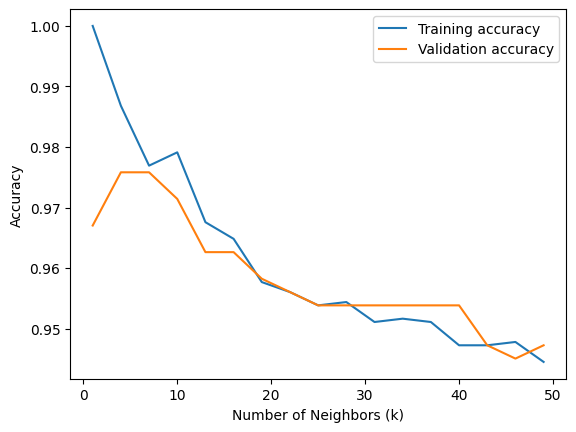

In [ ]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 52, 3)

train_scores, test_scores = validation_curve(
    KNeighborsClassifier(),
    X_train, y_train,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5
)

plt.plot(param_range, train_scores.mean(axis=1), label="Training accuracy")
plt.plot(param_range, test_scores.mean(axis=1), label="Validation accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The curve shows a clear bias–variance trade-off. The training accuracy starts at 1.0 for `k=1`, where the model memorizes every point, and decreases as `k` grows. The validation accuracy tells the more interesting story: it starts around 0.967 at `k=1`, rises to a distinct peak of about 0.976 around `k=4`–`7`, and then slowly declines for larger `k`.

The plot therefore suggests that the optimal number of neighbors is small, around `k≈5`, rather than the larger values: beyond that point, additional smoothing only removes useful signal.

## 1.3 Decision Tree
The next classifier is a **Decision Tree**, which classifies a sample through a sequence of yes/no questions on the features. At each node it selects the feature and threshold that best separate the classes (according to an impurity criterion such as Gini or entropy), splitting the data into purer and purer subsets down to the leaves.

Unlike KNN, a decision tree is **invariant to feature scaling**: it reasons through thresholds on one feature at a time, so we can use the standardized data. The complexity of the model is instead governed by its **depth**: a deeper tree can represent more complex decision boundaries but is more prone to overfitting.

We first grow a tree with no depth limit.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, tree.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, tree.predict(X_test)))

Train accuracy: 1.0
Test accuracy: 0.9385964912280702


The training accuracy is 1.0: with no depth constraint, the tree keeps splitting until every leaf is pure, perfectly memorizing the training set. This is a textbook case of **overfitting**, the model adapts to the noise in the training data, and the gap between training and test accuracy reveals that some of what it learned does not generalize. To control this, we limit the maximum depth.

In [ ]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, small_tree.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, small_tree.predict(X_test)))

Train accuracy: 0.9758241758241758
Test accuracy: 0.9385964912280702


Limiting the depth to 3 lowers the training accuracy from 1.0 to about 0.976, while the test accuracy stays exactly the same (0.939). The depth limit has therefore removed overfitting at no cost in generalization: the gap between training and test almost disappears, and we obtain the same predictive performance with a much simpler model.

### Confusion Matrix
Accuracy summarizes performance in a single number, but it hides how the model is making its errors. The confusion matrix shows this in detail: it reports, for each true class, how many samples were predicted in each class. The diagonal contains the correct predictions, the off-diagonal the mistakes, letting us see which kind of error the model tends to make.

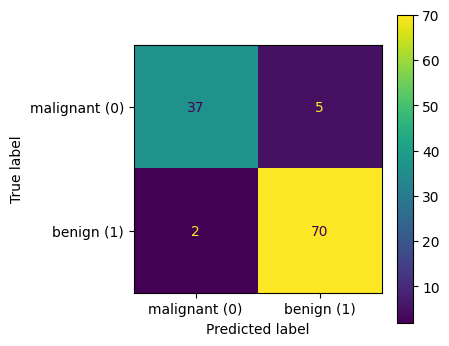

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cmp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, small_tree.predict(X_test)),
    display_labels=["malignant (0)", "benign (1)"]
)
fig, ax = plt.subplots(figsize=(4, 4))
cmp.plot(ax=ax)
plt.show()

The points on the diagonal are the correctly classified samples: 37 malignant and 70 benign tumors, the large majority of the test set. The off-diagonal entries are the two types of error, which in this medical setting are not equally serious. The top-right cell shows **5 false negatives** (malignant tumors classified as benign), the dangerous error, since it would fail to detect a real cancer. The bottom-left cell shows only **2 false positives** (benign tumors flagged as malignant) which cause unnecessary concern but no clinical harm.

It is worth looking beyond the overall accuracy here. The model misclassifies 7 samples out of 114, but the errors are concentrated on the more critical side: out of 42 truly malignant tumors it misses 5, i.e. about 12%. In other words, the recall on the malignant class (about 0.88) is lower than the overall accuracy (0.94). This is exactly the reason why, for a depth-3 tree, the confusion matrix gives a more truthful picture of the model's behaviour than accuracy alone.

### Validation curve on the depth
We fixed the depth to 3 somewhat arbitrarily. As we did for the number of neighbors in KNN, we now study how the performance varies systematically along a range of depths, to verify whether this choice is well placed with respect to the bias–variance trade-off.

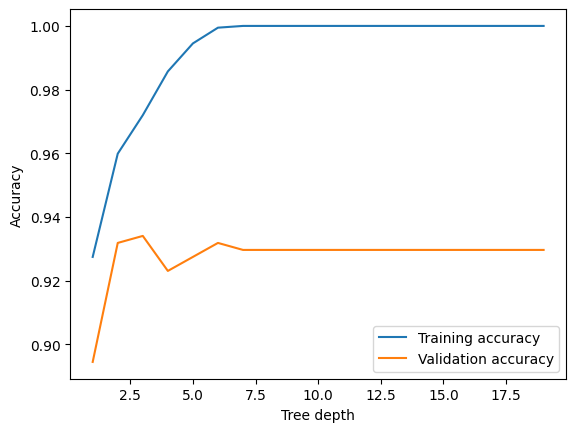

In [ ]:
param_range = np.arange(1, 20)

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5
)

plt.plot(param_range, train_scores.mean(axis=1), label="Training accuracy")
plt.plot(param_range, test_scores.mean(axis=1), label="Validation accuracy")
plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The two curves show the trade-off clearly. The training accuracy grows steadily with depth and reaches 1.0 around depth 6–7, after which the tree memorizes the training set completely. The validation accuracy behaves very differently: it is low at depth 1 (about 0.895, where the tree is too simple and underfits), jumps to its maximum already at depth 2–3 (about 0.93), and then stays essentially flat for all larger depths.

The growing gap between the two curves is precisely the signature of overfitting: the deeper tree learns details of the training data that do not generalize. The optimal complexity is therefore small, around depth 2–3.

### Classification report
If we wish to show a report of all the validation measures, we can use the classification report, even if some of these quantities have already been computed and commented in the Confusion matrix subsection.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, small_tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        42
           1       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



## 1.4 Naive Bayes
The next classifier is **Gaussian Naive Bayes**, a probabilistic method based on Bayes' theorem. To make the computation tractable, recall that we are assuming that the features are conditionally independent given the class.

This is an interesting model to test here precisely because we observed a strong multicollinearity among some features and we therefore expect Naive Bayes to be penalized to some extent.

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, gnb.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, gnb.predict(X_test)))

Train accuracy: 0.9428571428571428
Test accuracy: 0.9298245614035088


Naive Bayes reaches a train accuracy of about 0.943 and a test accuracy of about 0.930, very close to each other: no overfitting, as expected from such a simple model. Its test accuracy is solid but slightly below KNN and the decision tree, consistent with the violated independence assumption seen in the correlation matrix.

### Cross validation
The accuracies so far come from a single train/test split, which may depend on the particular partition. With **k-fold cross validation** the data is divided into 10 folds, each used once as test set: the mean of the scores gives a more reliable estimate of performance, and their standard deviation measures how stable it is.

In [ ]:
from sklearn.model_selection import cross_val_score

gnb = GaussianNB()
scores = cross_val_score(gnb, X, y, cv=10)
print("10-Fold CV scores:", scores)
print("Mean CV score:", scores.mean())
print("Std CV score:", scores.std())

10-Fold CV scores: [0.94736842 0.87719298 0.89473684 0.92982456 0.94736842 0.96491228
 0.92982456 0.96491228 0.94736842 0.96428571]
Mean CV score: 0.9367794486215537
Std CV score: 0.02844425208918023


The mean CV accuracy (0.937) matches the single-split result, while the moderate standard deviation (0.028, with folds ranging from 0.88 to 0.96) shows low sensitivity to the partition.

## 1.5 SVM
Another classifier is the **Support Vector Machine**, which separates the two classes with the boundary that maximizes the margin, i.e. the distance to the closest points of each class. We use an **RBF kernel**, which allows the model to capture non-linear boundaries, with its two hyperparameters: **C**, balancing margin width against classification errors, and **γ**, setting how local the influence of each training point is. Being a distance-based method, the SVM genuinely requires the standardized data we prepared earlier.

In [ ]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)
svm_rbf.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, svm_rbf.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, svm_rbf.predict(X_test)))

Train accuracy: 0.9912087912087912
Test accuracy: 0.9649122807017544


With default hyperparameters the SVM reaches a train accuracy of 0.991 and a test accuracy of 0.965, the best test result among the classifiers tested so far, on par with the strongest KNN configuration. The gap between train and test (about 0.026) is small but slightly wider than for Naive Bayes, suggesting a mild degree of overfitting that a smaller C, by widening the margin, might reduce. This gives us a concrete reason to tune the hyperparameters, which we do next.

### Hyperparameter tuning
We run a **grid search** over C and γ, evaluating each combination with cross validation. The best parameters turn out to be the default ones, so the tuned model coincides with the baseline SVM.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_

Best parameters: {'C': 1, 'gamma': 'scale'}


## 1.6 RIPPER
The last classifier we test is **RIPPER**, a rule-learning algorithm that produces an ordered list of explicit rules of the form *IF condition AND condition THEN class*. It builds rules incrementally and prunes them to reduce overfitting, yielding a compact and directly readable model. As we already said it is well suited to settings where the classes are not perfectly balanced, which is the case here.

In [ ]:
#!pip install wittgenstein

In [ ]:
from wittgenstein import RIPPER

ripper = RIPPER(random_state=42)
ripper.fit(X_train, y_train)
print("Train accuracy:", accuracy_score(y_train, ripper.predict(X_train)))
print("Test accuracy:", accuracy_score(y_test, ripper.predict(X_test)))

Train accuracy: 0.9406593406593406
Test accuracy: 0.9385964912280702


RIPPER reaches a train accuracy of about 0.940 and a test accuracy of about 0.940, below only SVM and KNN. Being a rule learner, it expresses the model as a short list of explicit IF–THEN rules. In order to make this condition readble we have to de-standardize the thresholds through the inverse transform of the scaler, recovering the conditions in the original units of each measurement.

In [ ]:
ripper.out_model()

[[20=-0.47--0.28] V
[20=-0.61--0.47] V
[0=<-1.11] V
[0=-1.11--0.78] V
[22=-0.76--0.62] V
[22=-0.29--0.057] V
[22=-0.057-0.28 ^ 3=-0.12-0.12 ^ 20=-0.061-0.26] V
[0=-0.78--0.61] V
[23=-0.35--0.18] V
[27=-0.66--0.46] V
[1=<-1.19] V
[2=-0.6--0.41]]


In [ ]:
id2name = {i: df.drop(columns=["diagnosis"]).columns[i] for i in range(df.shape[1]-1)}

In [ ]:
def inv(scaler, feat, val, X_train):
    return scaler.inverse_transform([
        [0]*feat +
        [val] +
        [0]*(X_train.shape[1]-feat-1)
    ])[0][feat]

In [ ]:
def print_ripper(ripper, scaler, X_train, id2name):
    for r in ripper.ruleset_:
        rule = ""
        for i, c in enumerate(r.conds):
            if isinstance(c.val, float):
                v = inv(scaler, c.feature, c.val, X_train)
                cond = f"({id2name[c.feature]} = {v:.2f})"
            elif isinstance(c.val, str) and ' - ' in c.val:
                lr, rr = c.val.split(' - ')
                cond = f"({id2name[c.feature]} from {inv(scaler, c.feature, float(lr), X_train):.2f}"
                cond += f" to {inv(scaler, c.feature, float(rr), X_train):.2f})"
            elif isinstance(c.val, str) and '<' in c.val:
                _, val = c.val.split('<')
                cond = f"({id2name[c.feature]} < {inv(scaler, c.feature, float(val), X_train):.2f})"
            elif isinstance(c.val, str) and '>' in c.val:
                _, val = c.val.split('>')
                cond = f"({id2name[c.feature]} > {inv(scaler, c.feature, float(val), X_train):.2f})"
            else:
                cond = f"({id2name[c.feature]} = {c.val})"
            rule += ("IF " if i == 0 else "AND ") + cond + " "
        print(rule + f"THEN target = {np.argmax(r.class_freqs_)}")

In [ ]:
print_ripper(ripper, scaler, X_train, id2name)

IF (worst radius from 13.98 to 14.93) THEN target = 1
IF (worst radius from 13.29 to 13.98) THEN target = 1
IF (mean radius < 10.16) THEN target = 1
IF (mean radius from 10.16 to 11.34) THEN target = 1
IF (worst perimeter from 81.42 to 86.24) THEN target = 1
IF (worst perimeter from 97.59 to 105.61) THEN target = 1
IF (worst perimeter from 105.61 to 117.21) AND (mean area from 613.90 to 699.22) AND (worst radius from 16.01 to 17.60) THEN target = 1
IF (mean radius from 11.34 to 11.95) THEN target = 1
IF (worst area from 682.61 to 782.79) THEN target = 1
IF (worst concave points from 0.07 to 0.09) THEN target = 1
IF (mean texture < 14.31) THEN target = 1
IF (mean perimeter from 77.20 to 81.88) THEN target = 1


A practical advantage of RIPPER is that its rules can be read directly in the original units of the measurements, giving each condition a concrete, physical meaning. All the rules conclude `target = 1`, so the model works by characterizing the **benign** class through explicit thresholds, and labels as malignant any sample that satisfies none of them. The conditions match medical intuition: a tumor with `mean radius < 10.16`, or with `mean texture < 14.31` (a uniform, low-variability nucleus), is classified as benign. This makes the decision process fully transparent and readable.

## Conclusions
Overall, all the classifiers tested perform well on this dataset, which proves to be well suited to a classification task thanks to its strongly separable classes. Within this generally good picture, however, a few meaningful differences emerge, consistent with what the exploratory analysis had anticipated.

As expected from the strong multicollinearity observed in the correlation matrix, **Naive Bayes** is the model with the lowest validation accuracy: its assumption of conditional independence between features is clearly violated, since the correlated size measurements carry largely redundant information. For the **decision tree**, the confusion matrix revealed a lower recall on the malignant class, which is particularly relevant in this medical context, because it corresponds precisely to malignant tumors being diagnosed as benign, the most dangerous type of error.

The best classifiers are **SVM** and **KNN**, both reaching a test accuracy of about 0.96, with the decision tree, Naive Bayes and RIPPER following closely at around 0.93–0.94. It is worth noting, however, that KNN matched the level of SVM only on the non-standardized data: there, the size-related features, which are also the most informative for the diagnosis, dominated the Euclidean distance because of their large scale, and this dominance happened to help rather than hurt. SVM, by contrast, reaches the same level on properly standardized data, which makes it the most solid and principled choice on this problem.